In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
train = pd.read_csv("../data/processed/train_merged.csv")
test = pd.read_csv("../data/processed/test_merged.csv")

## Basic Overview

In [6]:
print(train.shape)

train.head()

train.info()

train.describe().T

(590540, 434)
<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), str(31)
memory usage: 1.9 GB


,count,mean,std,min,25%,50%,75%,max
TransactionID,590540.0,3.282270e+06,1.704744e+05,2987000.000,3134634.750,3282269.500,3429904.25,3.577539e+06
isFraud,590540.0,3.499001e-02,1.837546e-01,0.000,0.000,0.000,0.00,1.000000e+00
TransactionDT,590540.0,7.372311e+06,4.617224e+06,86400.000,3027057.750,7306527.500,11246620.00,1.581113e+07
TransactionAmt,590540.0,1.350272e+02,2.391625e+02,0.251,43.321,68.769,125.00,3.193739e+04
card1,590540.0,9.898735e+03,4.901170e+03,1000.000,6019.000,9678.000,14184.00,1.839600e+04
...,...,...,...,...,...,...,...,...
id_22,5169.0,1.600271e+01,6.897665e+00,10.000,14.000,14.000,14.00,4.400000e+01
id_24,4747.0,1.280093e+01,2.372447e+00,11.000,11.000,11.000,15.00,2.600000e+01
id_25,5132.0,3.296089e+02,9.746109e+01,100.000,321.000,321.000,371.00,5.480000e+02
id_26,5163.0,1.490703e+02,3.210199e+01,100.000,119.000,149.000,169.00,2.160000e+02


## Fraud distribution

In [7]:
train["isFraud"].value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

In [8]:
train["isFraud"].value_counts(normalize=True) * 100

isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64

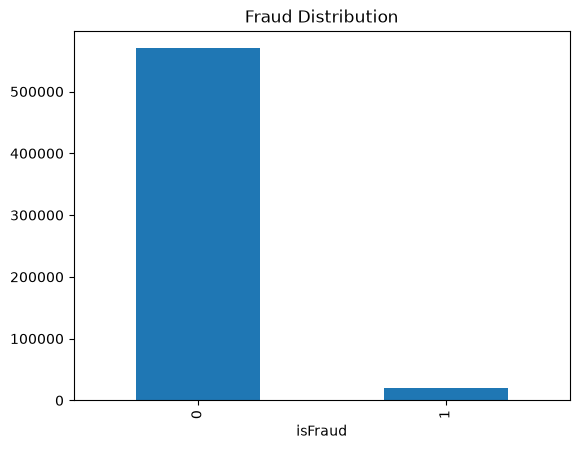

In [9]:
train["isFraud"].value_counts().plot(kind="bar")

plt.title("Fraud Distribution")

plt.show()

## Missing value analysis

In [10]:
def missing_report(df):

    missing = pd.DataFrame({

        "MissingCount": df.isnull().sum(),

        "MissingPercent": df.isnull().mean()*100

    })

    return missing.sort_values(
        "MissingPercent",
        ascending=False
    )

In [11]:
missing = missing_report(train)

missing.head(30)

,MissingCount,MissingPercent
id_24,585793,99.196159
id_25,585408,99.130965
id_07,585385,99.127070
id_08,585385,99.127070
id_21,585381,99.126393
id_26,585377,99.125715
id_27,585371,99.124699
id_23,585371,99.124699
id_22,585371,99.124699
dist2,552913,93.628374


In [28]:
missing

,MissingCount,MissingPercent
id_24,585793,99.196159
id_25,585408,99.130965
id_07,585385,99.127070
id_08,585385,99.127070
id_21,585381,99.126393
...,...,...
C11,0,0.000000
C14,0,0.000000
C13,0,0.000000
C12,0,0.000000


## datatypes

In [12]:
train.dtypes.value_counts()

float64    399
str         31
int64        4
Name: count, dtype: int64

In [13]:
numeric_columns = train.select_dtypes(
    include=np.number
).columns

categorical_columns = train.select_dtypes(
    exclude=np.number
).columns

In [14]:
print(len(numeric_columns))

print(len(categorical_columns))

403
31


## cardinality analysis

In [15]:
cardinality = train[categorical_columns].nunique()

cardinality.sort_values(
    ascending=False
).head(30)

DeviceInfo       1786
id_33             260
id_31             130
id_30              75
R_emaildomain      60
P_emaildomain      59
ProductCD           5
card6               4
card4               4
id_34               4
id_15               3
M4                  3
id_23               3
M2                  2
M1                  2
id_12               2
M9                  2
M8                  2
M7                  2
M6                  2
M5                  2
M3                  2
id_27               2
id_28               2
id_29               2
id_16               2
id_35               2
id_36               2
id_37               2
id_38               2
dtype: int64

## Numerical distribution

In [16]:
skewness = train[numeric_columns].skew()

skewness.sort_values(
    ascending=False
).head(30)

V305    384.226170
V311    323.831374
V129    240.274253
V309    224.875268
V206    207.881617
V319    181.833654
V269    177.838951
V266    175.958772
V334    168.472807
V135    144.883182
V321    123.556475
V214    119.173603
V336    118.722963
V276    108.717969
V227     99.428666
V241     91.520567
V137     90.583119
V278     90.283581
V131     89.595351
C3       88.949746
V337     85.771166
V205     84.904792
V240     80.114124
V245     76.513293
V312     73.603386
V216     73.493869
V320     70.515555
V277     69.369612
V268     69.165366
V259     60.747901
dtype: float64

## Correlation with target

In [17]:
correlation = train.corr(
    numeric_only=True
)["isFraud"]

correlation = correlation.sort_values(
    ascending=False
)

correlation.head(20)

isFraud    1.000000
V257       0.383060
V246       0.366878
V244       0.364129
V242       0.360590
V201       0.328005
V200       0.318783
V189       0.308219
V188       0.303582
V258       0.297151
V45        0.281832
V158       0.278066
V156       0.275952
V149       0.273282
V228       0.268861
V44        0.260376
V86        0.251828
V87        0.251737
V170       0.249794
V147       0.242894
Name: isFraud, dtype: float64

In [18]:
correlation.tail(20)

D4      -0.067216
V36     -0.069875
V11     -0.071950
D10     -0.072002
V10     -0.074658
V35     -0.077116
D15     -0.077519
D2      -0.083583
id_07   -0.084768
V70     -0.100900
V30     -0.103088
V69     -0.104521
V91     -0.105453
V29     -0.107852
V90     -0.110168
V49     -0.110920
V48     -0.115786
id_01   -0.120099
D7      -0.127199
D8      -0.142636
Name: isFraud, dtype: float64

## Constant features

In [19]:
constant_features = []

for col in train.columns:

    if train[col].nunique(dropna=False) <= 1:

        constant_features.append(col)

print(constant_features)

[]


## Feature groups

In [25]:
transaction_features = [
    col for col in train.columns
    if not col.startswith("id_")
    and not col.startswith("V")
]

In [20]:
constant_features = []

for col in train.columns:

    if train[col].nunique(dropna=False) <= 1:

        constant_features.append(col)

print(constant_features)

[]


In [21]:
identity_features = [
    col for col in train.columns
    if col.startswith("id_")
]

In [22]:
v_features = [
    col for col in train.columns
    if col.startswith("V")
]

In [26]:
print("Transaction:", len(transaction_features))

print("Identity:", len(identity_features))

print("V Features:", len(v_features))

Transaction: 57
Identity: 38
V Features: 339


## EDA Findings

- Dataset contains _____ rows and _____ columns.
- Fraud rate is _____%.
- Numerical columns: _____
- Categorical columns: _____
- Columns with >70% missing values: _____
- Constant columns: _____
- High-cardinality columns: _____
- Strongest positively correlated features: _____
- Strongest negatively correlated features: _____

### Decisions

- Remove high-missing columns? (Yes/No)
- Use tree-based model? (Yes)
- Need categorical encoding? (Yes)
- Need scaling? (Probably not for XGBoost)
- Handle class imbalance? (Yes)